# Performance Testing

## ideas
- general statistical methods for evaluation
- downstream task: train two models and use real data as validation set

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance

In [26]:
real = pd.read_csv("datasets/filtered.csv", engine="pyarrow")
synth = pd.read_csv("output/output.csv", engine="pyarrow")

In [27]:
numeric_cols = real.select_dtypes(include=np.number).columns.intersection(
    synth.select_dtypes(include=np.number).columns
)

selected_cols = [
    'st_dirs',
    'st_successful',
    'st_failed',
    'st_expired',
    'st_canceled',
    'st_faults',
    'st_bytes_xfered',
    'st_xfer_time_ms'
]

# Ensure both datasets contain these columns
real = real[selected_cols].dropna()
synth = synth[selected_cols].dropna()

print(f"Validating {len(selected_cols)} transfer-related features.\n")

Validating 8 transfer-related features.



In [28]:
column = "st_xfer_time_ms"
k = 3  # number of sigmas

# Compute statistics
mu = real[column].mean()
sigma = real[column].std()

# Filter DataFrame
real_filtered = real[(real[column] >= mu - k * sigma) &
                 (real
                [column] <= mu + k * sigma)]
synth_filtered = synth[(synth[column] >= mu - k * sigma) &
                 (synth
                [column] <= mu + k * sigma)]

In [29]:
stats_real = real.describe().T[['mean', 'std', 'min', 'max']]
stats_synth = synth.describe().T[['mean', 'std', 'min', 'max']]
summary = pd.concat(
    [stats_real.add_suffix('_real'), stats_synth.add_suffix('_synth')],
    axis=1
)
print("Before Clipping")
print("Descriptive statistics (real vs synthetic):")
print(summary)

Before Clipping
Descriptive statistics (real vs synthetic):
                    mean_real      std_real  min_real      max_real  \
st_dirs          3.165675e+02  3.371757e+04       0.0  8.791225e+07   
st_successful    4.519742e+03  2.529234e+05       0.0  5.114859e+08   
st_failed        4.972352e+01  5.160599e+04       0.0  1.440816e+08   
st_expired       5.304780e+02  1.934975e+05       0.0  4.457491e+08   
st_canceled      9.686416e+02  1.760280e+05       0.0  2.807579e+08   
st_faults        5.122567e+00  7.664199e+01       0.0  1.182540e+05   
st_bytes_xfered  5.600996e+10  2.698348e+12       0.0  7.802815e+15   
st_xfer_time_ms  8.983515e+05  1.889429e+07       0.0  1.482032e+10   

                   mean_synth     std_synth  min_synth     max_synth  
st_dirs          2.433889e+02  1.570600e+04        0.0  6.511210e+07  
st_successful    4.564268e+06  8.712789e+09        0.0  4.333706e+13  
st_failed        0.000000e+00  0.000000e+00        0.0  0.000000e+00  
st_expired      

In [30]:
stats_real = real_filtered.describe().T[['mean', 'std', 'min', 'max']]
stats_synth = synth_filtered.describe().T[['mean', 'std', 'min', 'max']]
summary = pd.concat(
    [stats_real.add_suffix('_real'), stats_synth.add_suffix('_synth')],
    axis=1
)
print("Descriptive statistics (real vs synthetic):")
print(summary)

Descriptive statistics (real vs synthetic):
                    mean_real      std_real  min_real      max_real  \
st_dirs          2.554553e+02  1.779903e+04       0.0  2.800850e+07   
st_successful    3.524890e+03  1.387929e+05       0.0  2.491708e+08   
st_failed        4.343018e+01  4.764330e+04       0.0  1.440816e+08   
st_expired       3.151090e+02  1.309443e+05       0.0  3.571345e+08   
st_canceled      7.177893e+02  1.396544e+05       0.0  2.795662e+08   
st_faults        4.420918e+00  5.667110e+01       0.0  3.433400e+04   
st_bytes_xfered  3.297271e+10  7.222208e+11       0.0  4.453716e+14   
st_xfer_time_ms  3.601259e+05  2.615780e+06       0.0  5.758037e+07   

                   mean_synth     std_synth  min_synth     max_synth  
st_dirs          2.431231e+02  1.572058e+04        0.0  6.511210e+07  
st_successful    4.571685e+06  8.721625e+09        0.0  4.333706e+13  
st_failed        0.000000e+00  0.000000e+00        0.0  0.000000e+00  
st_expired       3.948451e+00  2

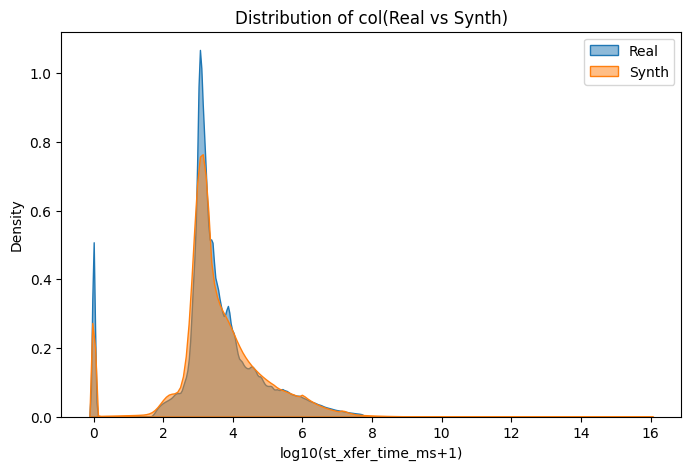

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
 
# Plot the distributions
col = "st_xfer_time_ms"
plt.figure(figsize=(8, 5))

real_log = np.log10(real_filtered[col].clip(lower=1))
synth_log = np.log10(synth[col].clip(lower=1))

sns.kdeplot(real_log, label="Real", fill=True, alpha=0.5)

sns.kdeplot(synth_log, label="Synth", fill=True, alpha=0.5)
 
plt.title("Distribution of col(Real vs Synth)")

plt.xlabel(f'log10({col}+1)')

plt.ylabel("Density")

plt.legend()

plt.show()



In [7]:
ks_results, wd_results = {}, {}
for col in selected_cols:
    ks = ks_2samp(real_filtered[col], synth[col]).statistic
    wd = wasserstein_distance(real[col], synth[col])
    ks_results[col] = ks
    wd_results[col] = wd

ks_df = pd.DataFrame({'KS_stat': ks_results, 'Wasserstein': wd_results})
print("\nDistribution similarity (lower is better):")
print(ks_df.sort_values('KS_stat'))


Distribution similarity (lower is better):
                  KS_stat   Wasserstein
st_failed        0.000204  4.972352e+01
st_expired       0.003225  5.304533e+02
st_canceled      0.008187  9.608467e+02
st_faults        0.023131  5.006859e+00
st_xfer_time_ms  0.041358  7.315991e+08
st_successful    0.049669  3.671361e+07
st_dirs          0.065950  1.421402e+02
st_bytes_xfered  0.069061  9.238369e+11


In [17]:
# Should this be included in the code?

synth.loc[synth["st_bytes_xfered"] > real["st_bytes_xfered"].max(), "st_bytes_xfered"] = real["st_bytes_xfered"].max()
synth.loc[synth["st_xfer_time_ms"] > real["st_xfer_time_ms"].max(), "st_xfer_time_ms"] = real["st_xfer_time_ms"].max()

In [12]:
print("real")
print(np.percentile(real.st_bytes_xfered, 99))
print(np.percentile(real.st_bytes_xfered, 95))
print(np.percentile(real.st_bytes_xfered, 90))
print("synth")
print(np.percentile(synth.st_bytes_xfered, 99))
print(np.percentile(synth.st_bytes_xfered, 95))
print(np.percentile(synth.st_bytes_xfered, 90))


real
559270485228.0292
35716142276.899826
6277237687.3
synth
559270478267.4314
35716142205.7084
6277237688.835719


In [13]:
print("real")
print(np.percentile(real.st_xfer_time_ms, 99))
print(np.percentile(real.st_xfer_time_ms, 95))
print(np.percentile(real.st_xfer_time_ms, 90))
print(np.percentile(real.st_xfer_time_ms, 50))
print(np.percentile(real.st_xfer_time_ms, 30))
print("synth")
print(np.percentile(synth.st_xfer_time_ms, 99))
print(np.percentile(synth.st_xfer_time_ms, 95))
print(np.percentile(synth.st_xfer_time_ms, 90))
print(np.percentile(synth.st_xfer_time_ms, 50))
print(np.percentile(synth.st_xfer_time_ms, 30))

real
12940297.489999995
882872.049999997
172722.0
2193.0
1188.0
synth
12940294.22772494
882872.0494433767
172722.00100654244
2193.000002367652
1141.4172035962029


In [8]:
corr_real = real_filtered.corr()
corr_synth = synth.corr()

# Drop columns that annihilate correlation
zero_var = real_filtered.columns[(real_filtered.nunique() <= 1) | (synth.nunique() <= 1)]
real_corr_input = real_filtered.drop(columns=zero_var)
synth_corr_input = synth.drop(columns=zero_var)
corr_real = real_corr_input.corr()
corr_synth = synth_corr_input.corr()
corr_diff = np.linalg.norm(corr_real - corr_synth, 'fro')

corr_diff_matrix = (corr_real - corr_synth).abs()

# Flatten to pairs for readability
corr_diff_pairs = (
    corr_diff_matrix
    .where(np.triu(np.ones(corr_diff_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_diff_pairs.columns = ['Feature1', 'Feature2', 'Abs_Diff']

# Sort by difference magnitude
corr_diff_pairs = corr_diff_pairs.sort_values('Abs_Diff', ascending=False)
print("Top correlation differences:")
print(corr_diff)
print(corr_diff_pairs.head(10))


Top correlation differences:
0.9105364324510782
           Feature1         Feature2  Abs_Diff
1           st_dirs       st_expired  0.378237
2           st_dirs      st_canceled  0.330887
20  st_bytes_xfered  st_xfer_time_ms  0.259291
0           st_dirs    st_successful  0.237156
19        st_faults  st_xfer_time_ms  0.166004
10    st_successful  st_xfer_time_ms  0.052826
9     st_successful  st_bytes_xfered  0.047439
7     st_successful      st_canceled  0.044141
3           st_dirs        st_faults  0.031797
5           st_dirs  st_xfer_time_ms  0.028712
